# Invest & Expand: Optimal Allocation Simulation

Budget: **50,000 XIRECs** allocated across three pillars (as percentages 0–100, total ≤ 100):
- **Research** (x_R): `200_000 * log(1+x) / log(101)` — logarithmic growth
- **Scale** (x_S): `7 * x / 100` — linear growth  
- **Speed** (x_v): rank-based multiplier in [0.1, 0.9] across all 1000+ players

**PnL = Research × Scale × Speed_Multiplier − Budget_Used**

where `Budget_Used = (x_R + x_S + x_v) × 500` XIRECs.

In [1]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

BUDGET       = 50_000   # XIRECs total
PCT_TO_XIREC = 500      # 1 percentage point = 500 XIRECs
N_PLAYERS    = 1000

np.random.seed(42)

## Cell 2 — Pillar Functions

In [2]:
def research(x):
    """x in [0, 100] (percentage of budget)"""
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    """x in [0, 100]"""
    return 7 * x / 100

def budget_used(x_R, x_S, x_v):
    return (x_R + x_S + x_v) * PCT_TO_XIREC

def pnl(x_R, x_S, m, x_v=0):
    """PnL given fixed speed multiplier m and speed investment x_v."""
    return research(x_R) * scale(x_S) * m - budget_used(x_R, x_S, x_v)

def assign_multipliers(speed_investments, n=None):
    """
    Given an array of speed investments, return speed multipliers
    using competition ranking (ties share minimum rank).
    """
    investments = np.array(speed_investments, dtype=float)
    if n is None:
        n = len(investments)
    # competition rank: rank of player i = number of players strictly better + 1
    ranks = np.array([np.sum(investments > inv) + 1 for inv in investments], dtype=float)
    multipliers = 0.9 - (ranks - 1) / (n - 1) * 0.8
    return multipliers

# Quick sanity checks from the problem statement
ex1 = assign_multipliers([70, 70, 70, 50, 40, 40, 30])
ex2 = assign_multipliers([95, 20, 10])
print('Example 1 multipliers:', np.round(ex1, 4))
print('Example 2 multipliers:', np.round(ex2, 4))

Example 1 multipliers: [0.9    0.9    0.9    0.5    0.3667 0.3667 0.1   ]
Example 2 multipliers: [0.9 0.5 0.1]


## Cell 3 — Optimal Research / Scale Split

For a fixed combined budget `t = x_R + x_S` (speed already decided), maximize:

$$\text{Research}(x_R) \times \text{Scale}(t - x_R)$$

The first-order condition is:

$$\frac{t - x_R}{1 + x_R} = \ln(1 + x_R)$$

which we solve numerically.

    t    x_R*    x_S*          R×S
   20    6.10   13.90       82,649
   40   10.82   29.18      218,620
   60   15.13   44.87      378,488
   80   19.22   60.78      554,360
  100   23.14   76.86      742,336


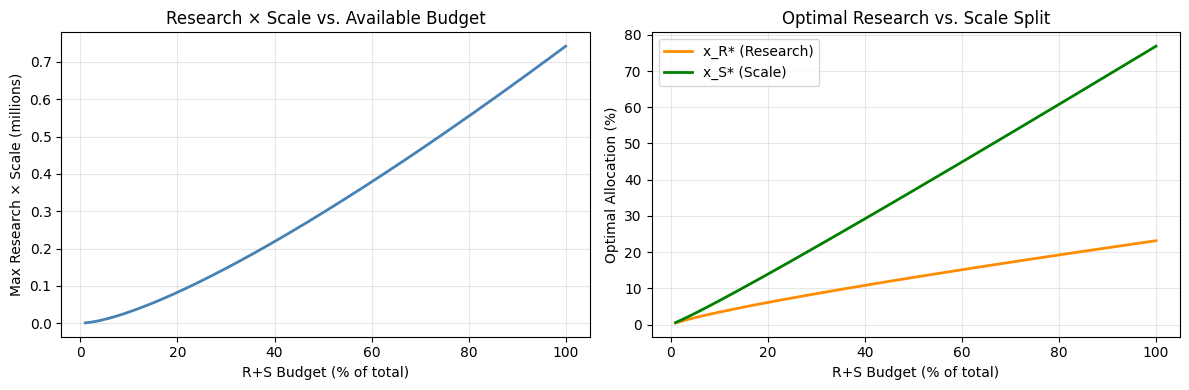

In [3]:
def optimal_RS(t):
    """
    Given R+S budget t (percentage points), find optimal split.
    Returns (x_R*, x_S*, max Research*Scale).
    """
    if t <= 0:
        return 0.0, 0.0, 0.0
    # FOC: (t - x_R)/(1 + x_R) = ln(1 + x_R)  =>  f(x_R) = 0
    def foc(x_R):
        return (t - x_R) / (1 + x_R) - np.log(1 + x_R)
    # x_R* in (0, t); bracket
    try:
        x_R_star = opt.brentq(foc, 1e-9, t - 1e-9)
    except ValueError:
        # FOC has no root in interior: optimum is at x_R=0 or x_R=t
        val_0 = research(0) * scale(t)
        val_t = research(t) * scale(0)
        x_R_star = 0.0 if val_0 >= val_t else t
    x_S_star = t - x_R_star
    rs_max = research(x_R_star) * scale(x_S_star)
    return x_R_star, x_S_star, rs_max

# Pre-compute for key budget levels
print(f"{'t':>5} {'x_R*':>7} {'x_S*':>7} {'R×S':>12}")
for t in [20, 40, 60, 80, 100]:
    xR, xS, rs = optimal_RS(t)
    print(f"{t:>5} {xR:>7.2f} {xS:>7.2f} {rs:>12,.0f}")

# Plot
t_vals = np.linspace(1, 100, 200)
rs_vals = np.array([optimal_RS(t)[2] for t in t_vals])
xR_vals = np.array([optimal_RS(t)[0] for t in t_vals])
xS_vals = np.array([optimal_RS(t)[1] for t in t_vals])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vals, rs_vals / 1e6, color='steelblue', lw=2)
axes[0].set_xlabel('R+S Budget (% of total)')
axes[0].set_ylabel('Max Research × Scale (millions)')
axes[0].set_title('Research × Scale vs. Available Budget')
axes[0].grid(alpha=0.3)

axes[1].plot(t_vals, xR_vals, label='x_R* (Research)', color='darkorange', lw=2)
axes[1].plot(t_vals, xS_vals, label='x_S* (Scale)', color='green', lw=2)
axes[1].set_xlabel('R+S Budget (% of total)')
axes[1].set_ylabel('Optimal Allocation (%)')
axes[1].set_title('Optimal Research vs. Scale Split')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 4 — PnL Landscape (Fixed Speed Multiplier)

With speed investment x_v fixed, what does the PnL surface look like over (x_R, x_S)?

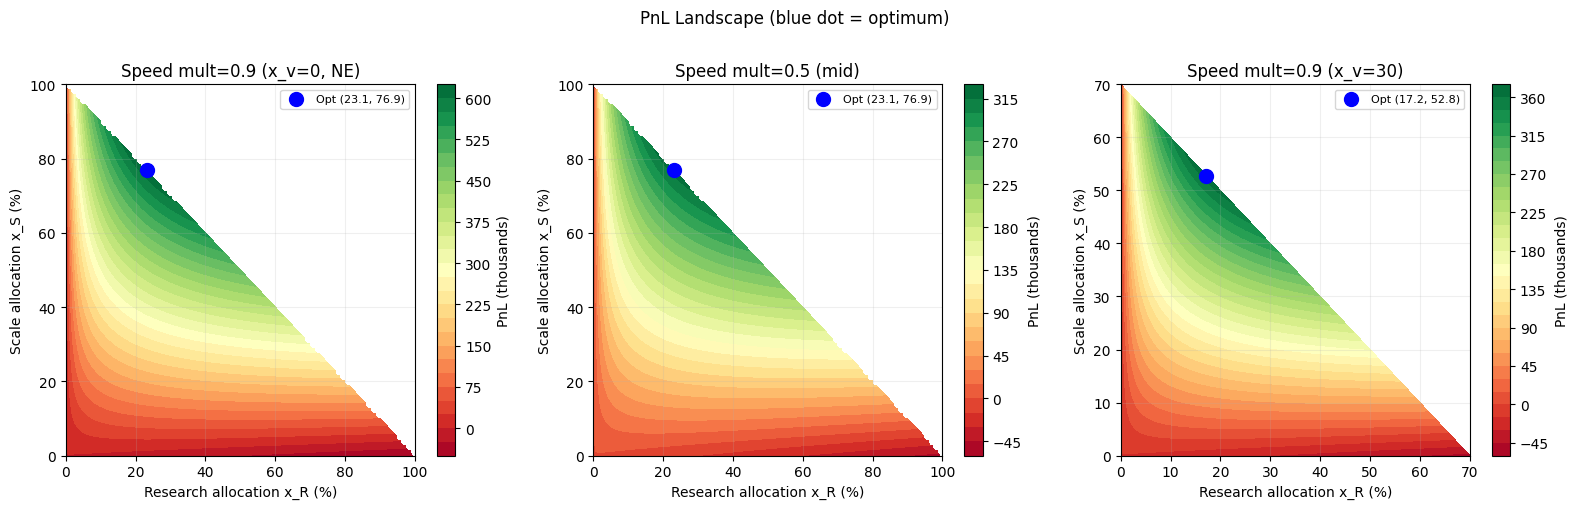


Nash Equilibrium allocation: x_R=23.1%, x_S=76.9%, x_v=0%
PnL at NE = 618,103 XIRECs


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (m, x_v, title) in zip(axes, [
    (0.9, 0,  'Speed mult=0.9 (x_v=0, NE)'),
    (0.5, 0,  'Speed mult=0.5 (mid)'),
    (0.9, 30, 'Speed mult=0.9 (x_v=30)'),
]):
    remaining = 100 - x_v
    x_R_grid = np.linspace(0, remaining, 150)
    x_S_grid = np.linspace(0, remaining, 150)
    XR, XS = np.meshgrid(x_R_grid, x_S_grid)
    # enforce budget constraint
    mask = (XR + XS) <= remaining
    PNL = np.where(mask, pnl(XR, XS, m, x_v), np.nan)

    im = ax.contourf(XR, XS, PNL / 1e3, levels=30, cmap='RdYlGn')
    plt.colorbar(im, ax=ax, label='PnL (thousands)')

    # mark optimal
    xR_opt, xS_opt, _ = optimal_RS(remaining)
    ax.scatter([xR_opt], [xS_opt], color='blue', s=100, zorder=5, label=f'Opt ({xR_opt:.1f}, {xS_opt:.1f})')
    ax.set_xlabel('Research allocation x_R (%)')
    ax.set_ylabel('Scale allocation x_S (%)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('PnL Landscape (blue dot = optimum)', y=1.01)
plt.tight_layout()
plt.show()

# Print optimal PnL for the NE case
xR, xS, rs = optimal_RS(100)
pnl_ne = rs * 0.9 - budget_used(xR, xS, 0)
print(f"\nNash Equilibrium allocation: x_R={xR:.1f}%, x_S={xS:.1f}%, x_v=0%")
print(f"PnL at NE = {pnl_ne:,.0f} XIRECs")

## Cell 5 — Speed Competition: Ranking Rules

**Competition ranking:** ties share the *minimum* rank of their group.  
- Rank 1 → multiplier 0.9  
- Rank n → multiplier 0.1  
- Linear interpolation: `mult(k) = 0.9 − (k−1)/(n−1) × 0.8`

**Key property:** if *all* n players tie (even at 0), they all get rank 1 → **multiplier = 0.9**.

=== Problem statement examples ===
  investment= 70  multiplier=0.9000
  investment= 70  multiplier=0.9000
  investment= 70  multiplier=0.9000
  investment= 50  multiplier=0.5000
  investment= 40  multiplier=0.3667
  investment= 40  multiplier=0.3667
  investment= 30  multiplier=0.1000

  investment= 95  multiplier=0.9000
  investment= 20  multiplier=0.5000
  investment= 10  multiplier=0.1000

All 1000 players invest 0%: multiplier = 0.9000
All 1000 players invest 20%: multiplier = 0.9000
All 1000 players invest 50%: multiplier = 0.9000
All 1000 players invest 100%: multiplier = 0.9000


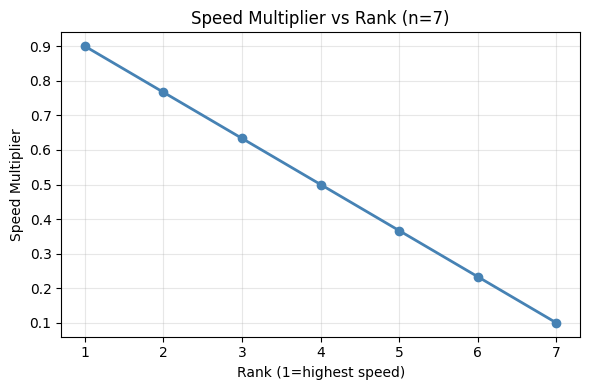

In [5]:
print("=== Problem statement examples ===")
ex1_inv = [70, 70, 70, 50, 40, 40, 30]
ex1_mult = assign_multipliers(ex1_inv)
for inv, m in zip(ex1_inv, ex1_mult):
    print(f"  investment={inv:3d}  multiplier={m:.4f}")

print()
ex2_inv = [95, 20, 10]
ex2_mult = assign_multipliers(ex2_inv)
for inv, m in zip(ex2_inv, ex2_mult):
    print(f"  investment={inv:3d}  multiplier={m:.4f}")

print()
# KEY INSIGHT: all tied at any value
for v in [0, 20, 50, 100]:
    all_same = [v] * N_PLAYERS
    m = assign_multipliers(all_same)
    print(f"All {N_PLAYERS} players invest {v}%: multiplier = {m[0]:.4f}")

# Visualize multiplier vs rank
n = 7
ranks = np.arange(1, n+1)
mults = 0.9 - (ranks - 1) / (n - 1) * 0.8
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ranks, mults, 'o-', color='steelblue', lw=2)
ax.set_xlabel('Rank (1=highest speed)')
ax.set_ylabel('Speed Multiplier')
ax.set_title(f'Speed Multiplier vs Rank (n={n})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 6 — Game Theory Analysis of Speed

### Part A — Pure Nash Equilibrium: s* = 0

**Claim:** In the symmetric game with n=1000+ players, investing **0% in speed** is a Nash Equilibrium.

**Proof:**  
- At s*=0: all players tie → all rank 1 → multiplier = 0.9  
- Deviation *up* (invest s > 0): still get multiplier 0.9 (you'd be rank 1 alone, others rank 2 with mult ≈ 0.8992), but you lose `s%` of budget from Research/Scale → **PnL strictly decreases**  
- Deviation *down*: already at 0, can't go lower  
- Therefore no profitable deviation exists → s*=0 is NE ✓

In [6]:
# Part A: Confirm deviation up is never profitable
xR_ne, xS_ne, rs_ne = optimal_RS(100)
pnl_ne = rs_ne * 0.9 - budget_used(xR_ne, xS_ne, 0)

print("Deviation analysis (others invest 0, I invest s):")
print(f"{'s (speed %)':>12} {'My mult':>10} {'My R+S budget':>14} {'My PnL':>12} {'vs NE':>12}")
for s in [0, 5, 10, 20, 30, 50]:
    # I'm rank 1 (alone), others are rank 2; my multiplier is still 0.9
    my_mult = 0.9
    xR_dev, xS_dev, rs_dev = optimal_RS(100 - s)
    pnl_dev = rs_dev * my_mult - budget_used(xR_dev, xS_dev, s)
    delta = pnl_dev - pnl_ne
    print(f"{s:>12} {my_mult:>10.4f} {100-s:>14} {pnl_dev:>12,.0f} {delta:>+12,.0f}")

print("\nConclusion: all deviations up yield ΔPnL < 0. s*=0 is NE.")

Deviation analysis (others invest 0, I invest s):
 s (speed %)    My mult  My R+S budget       My PnL        vs NE
           0     0.9000            100      618,103           +0
           5     0.9000             95      574,917      -43,185
          10     0.9000             90      532,305      -85,798
          20     0.9000             80      448,924     -169,179
          30     0.9000             70      368,246     -249,856
          50     0.9000             50      216,586     -401,516

Conclusion: all deviations up yield ΔPnL < 0. s*=0 is NE.


### Part B — Fragility: Risk Under Uncertainty

The s*=0 NE assumes all players are rational and coordinate on it. In practice, if a fraction **q** of players invest positive speed, non-investors fall in rank and get a lower multiplier.

With n=1000+: `multiplier_of_non-investor ≈ 0.9 − 0.8q`

Non-investor PnL as fraction q of opponents invest positive speed:
     q    My mult       My PnL
   0.0      0.900      618,103
   0.1      0.819      558,116
   0.3      0.658      438,142
   0.5      0.504      324,168
   0.7      0.342      204,194
   0.9      0.181       84,220
   1.0      0.100       24,234


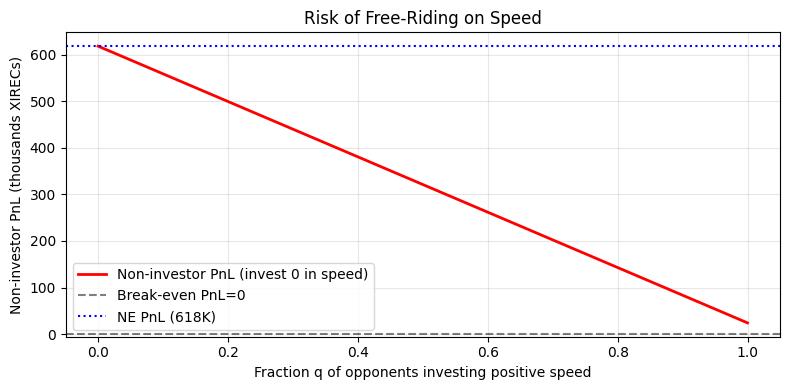

In [7]:
# Part B: Fragility
q_vals = np.linspace(0, 1, 100)

# If fraction q invests some s_other and I invest 0:
# my rank ≈ q*n + 1, my multiplier ≈ 0.9 - 0.8*q
mult_non_investor = 0.9 - 0.8 * q_vals

xR_opt, xS_opt, rs_opt = optimal_RS(100)
pnl_non_investor = rs_opt * mult_non_investor - budget_used(xR_opt, xS_opt, 0)

print("Non-investor PnL as fraction q of opponents invest positive speed:")
print(f"{'q':>6} {'My mult':>10} {'My PnL':>12}")
for q in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    idx = np.argmin(np.abs(q_vals - q))
    print(f"{q:>6.1f} {mult_non_investor[idx]:>10.3f} {pnl_non_investor[idx]:>12,.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_vals, pnl_non_investor / 1e3, 'r-', lw=2, label='Non-investor PnL (invest 0 in speed)')
ax.axhline(0, color='k', ls='--', alpha=0.5, label='Break-even PnL=0')
ax.axhline(pnl_ne / 1e3, color='blue', ls=':', lw=1.5, label=f'NE PnL ({pnl_ne/1e3:.0f}K)')
ax.set_xlabel('Fraction q of opponents investing positive speed')
ax.set_ylabel('Non-investor PnL (thousands XIRECs)')
ax.set_title('Risk of Free-Riding on Speed')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Part C — Best Response: Optimal Speed Given Opponent Distribution

In [8]:
def pnl_given_speed(s_mine, q, s_other, n=N_PLAYERS):
    """
    My PnL when I invest s_mine in speed.
    q fraction of n opponents invest s_other; rest invest 0.
    """
    # Simulate the ranking: q*n opponents at s_other, (1-q)*n at 0, plus me at s_mine
    n_high  = int(round(q * n))
    n_low   = n - n_high  # including me conceptually
    # Number of opponents strictly faster than me
    if s_mine > s_other:
        n_faster = 0
    elif s_mine == s_other:
        n_faster = 0  # tied with high group, share rank 1
    else:  # s_mine < s_other
        n_faster = n_high  # all high investors beat me
        if s_mine > 0:  # I beat the zero investors
            n_faster = n_high  # same
        # actually also check against 0 investors
        # if s_mine > 0 and s_other > 0: I beat the 0-group
        # my rank = n_high + 1 if s_mine > 0
        # my rank = n_high + n_low + 1 if s_mine == 0 (tied with low group → min rank = n_high+1)
    
    # Precise rank calculation
    all_speeds = np.array([s_other] * n_high + [0.0] * (n - n_high))
    n_strictly_faster = np.sum(all_speeds > s_mine)
    my_rank = n_strictly_faster + 1  # competition ranking
    total_players = n + 1  # n opponents + me
    my_mult = 0.9 - (my_rank - 1) / (total_players - 1) * 0.8
    my_mult = np.clip(my_mult, 0.1, 0.9)

    xR, xS, _ = optimal_RS(100 - s_mine)
    return research(xR) * scale(xS) * my_mult - budget_used(xR, xS, s_mine)

def best_response(q, s_other, s_grid=np.linspace(0, 100, 201)):
    pnls = [pnl_given_speed(s, q, s_other) for s in s_grid]
    return s_grid[np.argmax(pnls)], max(pnls)

# Show best response for selected (q, s_other) pairs
print(f"{'q':>6} {'s_other':>9} {'best s*':>9} {'best PnL':>12}")
for q in [0.1, 0.3, 0.5, 0.7, 0.9]:
    for s_o in [10, 30, 50]:
        s_star, p = best_response(q, s_o)
        print(f"{q:>6.1f} {s_o:>9} {s_star:>9.0f} {p:>12,.0f}")
    print()

     q   s_other   best s*     best PnL
   0.1        10         0      558,716
   0.1        30         0      558,716
   0.1        50         0      558,716

   0.3        10        10      532,305
   0.3        30         0      439,942
   0.3        50         0      439,942

   0.5        10        10      532,305
   0.5        30        30      368,246
   0.5        50         0      321,168

   0.7        10        10      532,305
   0.7        30        30      368,246
   0.7        50        50      216,586

   0.9        10        10      532,305
   0.9        30        30      368,246
   0.9        50        50      216,586



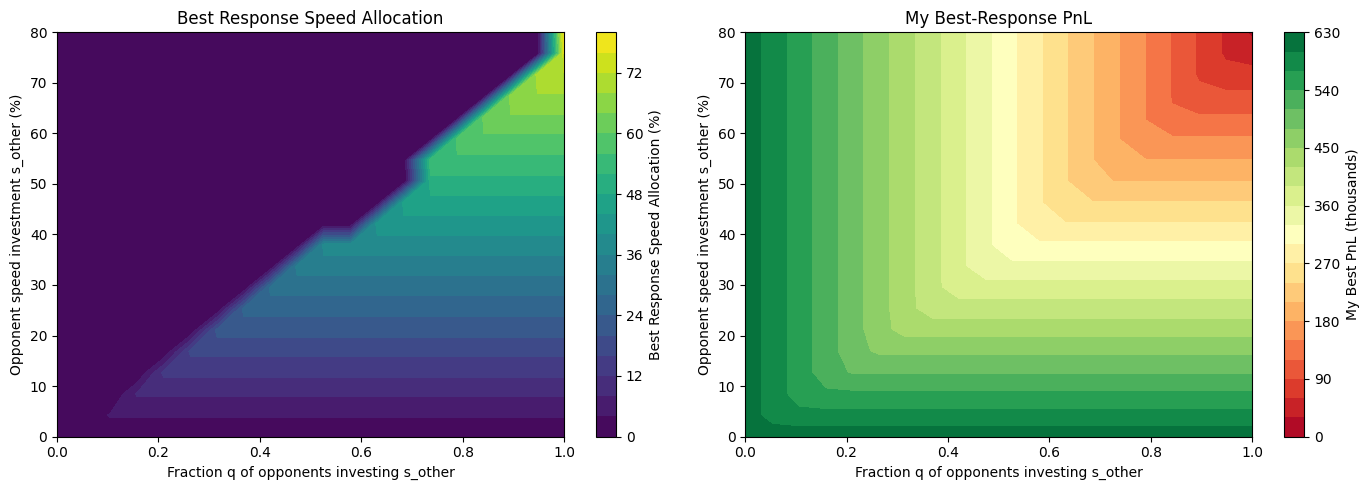

In [9]:
# Part C: 2D heatmap of best response speed over (q, s_other)
q_grid    = np.linspace(0, 1, 20)
s_o_grid  = np.linspace(0, 80, 20)
BR_map    = np.zeros((len(s_o_grid), len(q_grid)))
PNL_map   = np.zeros((len(s_o_grid), len(q_grid)))

for i, s_o in enumerate(s_o_grid):
    for j, q in enumerate(q_grid):
        BR_map[i, j], PNL_map[i, j] = best_response(q, s_o)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].contourf(q_grid, s_o_grid, BR_map, levels=20, cmap='viridis')
plt.colorbar(im1, ax=axes[0], label='Best Response Speed Allocation (%)')
axes[0].set_xlabel('Fraction q of opponents investing s_other')
axes[0].set_ylabel('Opponent speed investment s_other (%)')
axes[0].set_title('Best Response Speed Allocation')

im2 = axes[1].contourf(q_grid, s_o_grid, PNL_map / 1e3, levels=20, cmap='RdYlGn')
plt.colorbar(im2, ax=axes[1], label='My Best PnL (thousands)')
axes[1].set_xlabel('Fraction q of opponents investing s_other')
axes[1].set_ylabel('Opponent speed investment s_other (%)')
axes[1].set_title('My Best-Response PnL')

plt.tight_layout()
plt.show()

### Part D — Break-Even Analysis

At what fraction `q*` does it become worthwhile to **match** the leading group's speed `s_other`?

$$0.9 \cdot f(100 - s_{\text{other}}) = (0.9 - 0.8q^*) \cdot f(100)$$

$$q^* = \frac{0.9}{0.8}\left(1 - \frac{f(100-s_{\text{other}})}{f(100)}\right)$$

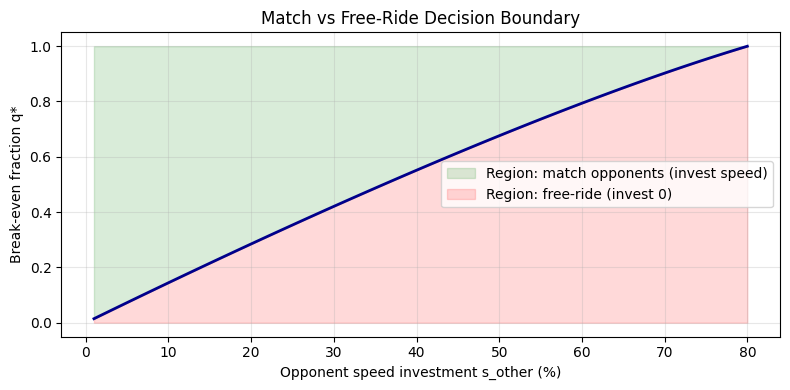

Break-even q* for selected s_other values:
  s_other=  5%  →  q* = 0.073  (match speed if >7.3% of opponents invest 5%)
  s_other= 10%  →  q* = 0.144  (match speed if >14.4% of opponents invest 10%)
  s_other= 20%  →  q* = 0.285  (match speed if >28.5% of opponents invest 20%)
  s_other= 30%  →  q* = 0.421  (match speed if >42.1% of opponents invest 30%)
  s_other= 50%  →  q* = 0.676  (match speed if >67.6% of opponents invest 50%)


In [10]:
_, _, rs_100 = optimal_RS(100)

s_other_range = np.linspace(1, 80, 100)
q_breakeven = []
for s_o in s_other_range:
    _, _, rs_t = optimal_RS(100 - s_o)
    # 0.9*rs_t = (0.9 - 0.8*q)*rs_100  =>  q = (0.9/0.8)*(1 - rs_t/rs_100)
    q_star = (0.9 / 0.8) * (1 - rs_t / rs_100)
    q_breakeven.append(np.clip(q_star, 0, 1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_other_range, q_breakeven, 'darkblue', lw=2)
ax.fill_between(s_other_range, q_breakeven, 1,
                alpha=0.15, color='green', label='Region: match opponents (invest speed)')
ax.fill_between(s_other_range, 0, q_breakeven,
                alpha=0.15, color='red', label='Region: free-ride (invest 0)')
ax.set_xlabel('Opponent speed investment s_other (%)')
ax.set_ylabel('Break-even fraction q*')
ax.set_title('Match vs Free-Ride Decision Boundary')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Break-even q* for selected s_other values:")
for s_o in [5, 10, 20, 30, 50]:
    _, _, rs_t = optimal_RS(100 - s_o)
    q_star = (0.9 / 0.8) * (1 - rs_t / rs_100)
    print(f"  s_other={s_o:3d}%  →  q* = {q_star:.3f}  (match speed if >{q_star*100:.1f}% of opponents invest {s_o}%)")

## Cell 7 — Full Simulation: 1000 Players

Simulate a single-round game with mixed strategies and record each player's PnL.

In [11]:
def simulate_game(strategy_dist, n=N_PLAYERS, rng=None):
    """
    strategy_dist: list of (name, fraction, x_v_func) where x_v_func() → speed %.
    Returns DataFrame-like dict with per-player results.
    """
    if rng is None:
        rng = np.random.default_rng(42)
    
    names, speeds, pnls = [], [], []
    total_assigned = 0
    
    for name, frac, x_v_func in strategy_dist:
        k = round(frac * n)
        for _ in range(k):
            x_v = float(np.clip(x_v_func(rng), 0, 100))
            names.append(name)
            speeds.append(x_v)
        total_assigned += k
    
    speeds = np.array(speeds[:n])
    names  = names[:n]
    actual_n = len(speeds)
    
    # Assign multipliers
    mults = assign_multipliers(speeds, n=actual_n)
    
    # Compute each player's PnL (optimal R/S split given their speed investment)
    for i, (x_v, m) in enumerate(zip(speeds, mults)):
        xR, xS, _ = optimal_RS(100 - x_v)
        p = research(xR) * scale(xS) * m - budget_used(xR, xS, x_v)
        pnls.append(p)
    
    return names, speeds, mults, np.array(pnls)


# Define strategy distributions
strategies = [
    ('no-speed (0%)',       0.25, lambda rng: 0),
    ('low-speed (10%)',     0.25, lambda rng: 10),
    ('medium-speed (30%)',  0.25, lambda rng: 30),
    ('random (0-60%)',      0.25, lambda rng: rng.uniform(0, 60)),
]

names, speeds, mults, pnls = simulate_game(strategies)

# Summary statistics per strategy
unique_names = [s[0] for s in strategies]
print(f"{'Strategy':<22} {'Count':>6} {'Avg Speed':>10} {'Avg Mult':>10} {'Avg PnL':>12} {'Med PnL':>12}")
for nm in unique_names:
    mask = np.array(names) == nm
    if mask.sum() == 0:
        continue
    print(f"{nm:<22} {mask.sum():>6} {speeds[mask].mean():>10.1f} "
          f"{mults[mask].mean():>10.4f} {pnls[mask].mean():>12,.0f} {np.median(pnls[mask]):>12,.0f}")

Strategy                Count  Avg Speed   Avg Mult      Avg PnL      Med PnL
no-speed (0%)             250        0.0     0.2994      172,255      172,255
low-speed (10%)           250       10.0     0.5364      297,077      297,077
medium-speed (30%)        250       30.0     0.8015      322,472      322,472
random (0-60%)            250       29.8     0.6618      232,647      239,085


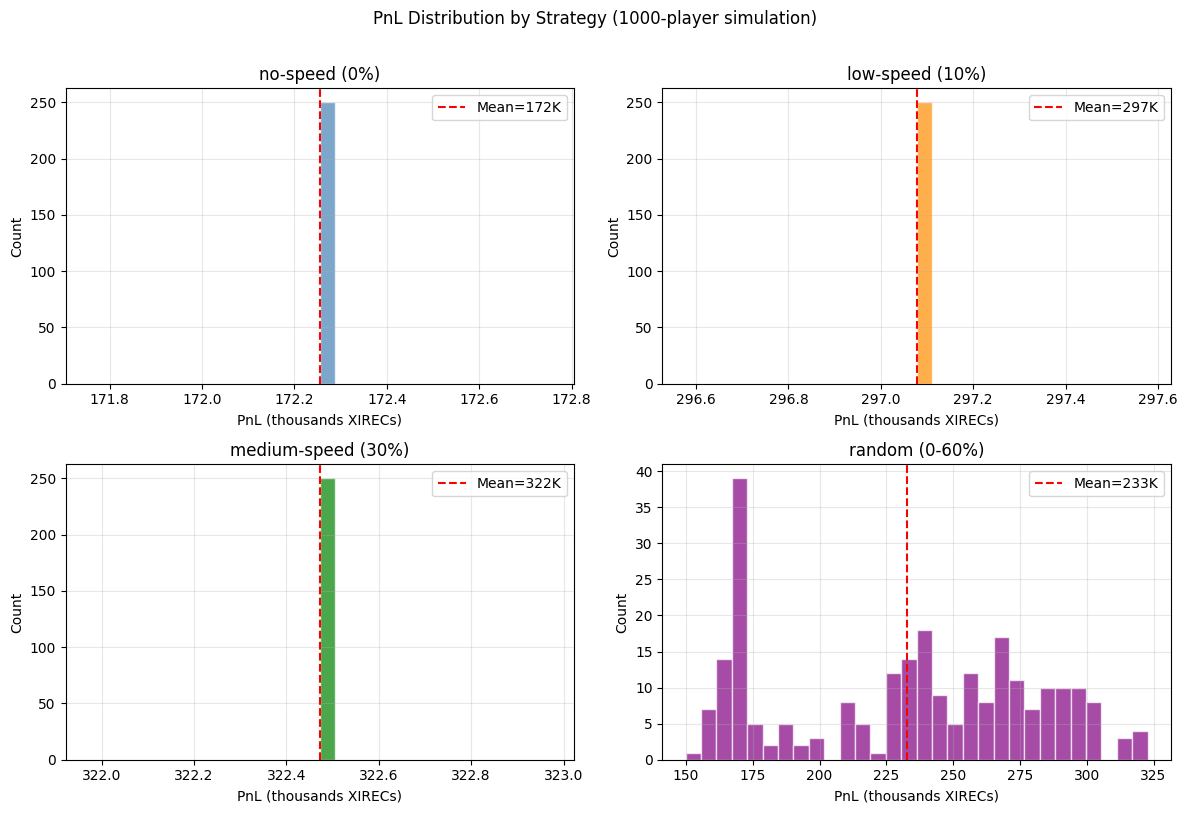

In [12]:
# Plot PnL distributions per strategy
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['steelblue', 'darkorange', 'green', 'purple']

for ax, (nm, col) in zip(axes.flatten(), zip(unique_names, colors)):
    mask = np.array(names) == nm
    p = pnls[mask]
    ax.hist(p / 1e3, bins=30, color=col, alpha=0.7, edgecolor='white')
    ax.axvline(p.mean() / 1e3, color='red', ls='--', lw=1.5, label=f'Mean={p.mean()/1e3:.0f}K')
    ax.set_title(nm)
    ax.set_xlabel('PnL (thousands XIRECs)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('PnL Distribution by Strategy (1000-player simulation)', y=1.01)
plt.tight_layout()
plt.show()

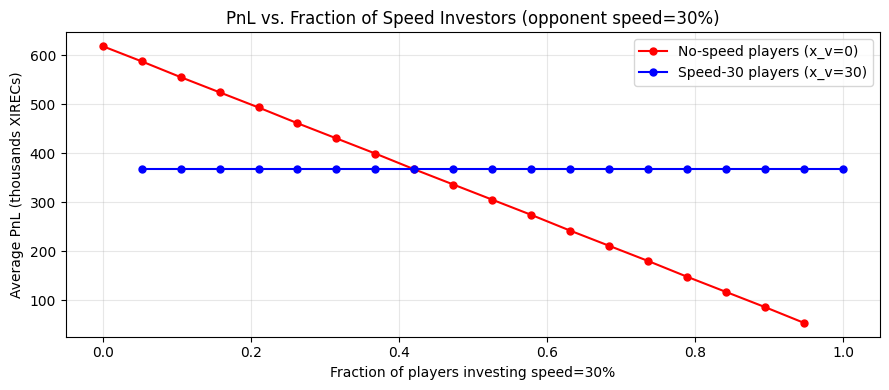

In [13]:
# Sweep: vary fraction of players using speed and show effect on non-investors
q_sweep = np.linspace(0, 1, 20)
avg_pnl_nospeed = []
avg_pnl_speed30 = []

for q in q_sweep:
    strat = [
        ('speed-30', q,   lambda rng: 30),
        ('no-speed', 1-q, lambda rng: 0),
    ]
    nm, sp, mu, pl = simulate_game(strat, n=500)
    nm_arr = np.array(nm)
    mask_ns = nm_arr == 'no-speed'
    mask_s  = nm_arr == 'speed-30'
    avg_pnl_nospeed.append(pl[mask_ns].mean() if mask_ns.sum() > 0 else np.nan)
    avg_pnl_speed30.append(pl[mask_s].mean()  if mask_s.sum()  > 0 else np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(q_sweep, np.array(avg_pnl_nospeed)/1e3, 'r-o', ms=5, label='No-speed players (x_v=0)')
ax.plot(q_sweep, np.array(avg_pnl_speed30)/1e3, 'b-o', ms=5, label='Speed-30 players (x_v=30)')
ax.set_xlabel('Fraction of players investing speed=30%')
ax.set_ylabel('Average PnL (thousands XIRECs)')
ax.set_title('PnL vs. Fraction of Speed Investors (opponent speed=30%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 8 — Optimal Allocation Summary & Recommendation

### Summary Table

In [14]:
print("=" * 80)
print("OPTIMAL ALLOCATION — INVEST & EXPAND")
print("=" * 80)

scenarios = [
    ("Conservative (NE, q=0)",      0,   0.9),
    ("Light hedge (q=0.2, s=10%)",  10,  None),
    ("Moderate hedge (q=0.5, s=30%)", 30, None),
    ("Aggressive (q=0.8, s=50%)",   50,  None),
]

print(f"\n{'Scenario':<35} {'x_R':>6} {'x_S':>6} {'x_v':>6} {'Mult':>7} {'PnL':>12}")
print("-" * 80)

for name, x_v, mult_override in scenarios:
    xR, xS, rs = optimal_RS(100 - x_v)
    if mult_override is None:
        # assume you match the leading group → you join them at rank 1 → 0.9
        m = 0.9
    else:
        m = mult_override
    p = rs * m - budget_used(xR, xS, x_v)
    print(f"{name:<35} {xR:>6.1f} {xS:>6.1f} {x_v:>6} {m:>7.2f} {p:>12,.0f}")

print("\n" + "=" * 80)
print("GAME THEORY INSIGHTS")
print("=" * 80)
print("""
1. PURE NE: x_v=0 is a Nash Equilibrium.
   If all players invest 0 in speed → all tie → all get multiplier 0.9.
   Deviating UP reduces R+S budget with no multiplier gain → suboptimal.

2. OPTIMAL UNCONDITIONAL ALLOCATION (NE):
   x_R ≈ 23%, x_S ≈ 77%, x_v = 0%  →  PnL ≈ 618,000 XIRECs

3. FRAGILITY: if fraction q of opponents invest speed s, non-investors get:
   multiplier ≈ 0.9 − 0.8q
   At q=0.5: multiplier ≈ 0.5  →  PnL ≈ 371,000 (−40% vs NE)
   At q=1.0: multiplier = 0.1  →  PnL ≈  24,000 (−96% vs NE)

4. BREAK-EVEN RULE: match opponents if q > q*(s_other)
   e.g., if ~11% of players invest 10% in speed, it pays to match them.

5. PRACTICAL RECOMMENDATION:
   - If confident in NE coordination: invest x_v = 0
   - If uncertain: invest x_v = median expected opponent speed
     (costs ~5–15% PnL but insures against 0.1 multiplier trap)
   - Key insight: NEVER invest MORE than the expected leader; extra speed
     only wastes R+S budget without multiplier benefit.
""")

OPTIMAL ALLOCATION — INVEST & EXPAND

Scenario                               x_R    x_S    x_v    Mult          PnL
--------------------------------------------------------------------------------
Conservative (NE, q=0)                23.1   76.9      0    0.90      618,103
Light hedge (q=0.2, s=10%)            21.2   68.8     10    0.90      532,305
Moderate hedge (q=0.5, s=30%)         17.2   52.8     30    0.90      368,246
Aggressive (q=0.8, s=50%)             13.0   37.0     50    0.90      216,586

GAME THEORY INSIGHTS

1. PURE NE: x_v=0 is a Nash Equilibrium.
   If all players invest 0 in speed → all tie → all get multiplier 0.9.
   Deviating UP reduces R+S budget with no multiplier gain → suboptimal.

2. OPTIMAL UNCONDITIONAL ALLOCATION (NE):
   x_R ≈ 23%, x_S ≈ 77%, x_v = 0%  →  PnL ≈ 618,000 XIRECs

3. FRAGILITY: if fraction q of opponents invest speed s, non-investors get:
   multiplier ≈ 0.9 − 0.8q
   At q=0.5: multiplier ≈ 0.5  →  PnL ≈ 371,000 (−40% vs NE)
   At q=1.0: mu

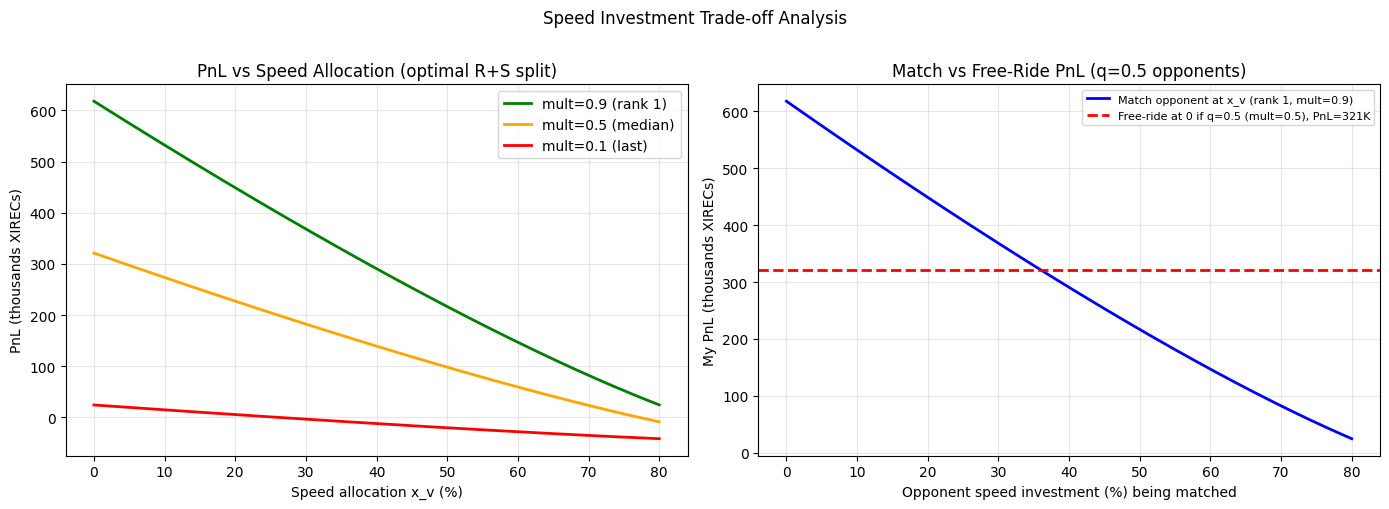

In [15]:
# Final summary visualization
xv_range = np.linspace(0, 80, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PnL vs speed investment for different multipliers (best-case = you're rank 1)
for m, color, label in [(0.9, 'green', 'mult=0.9 (rank 1)'),
                         (0.5, 'orange', 'mult=0.5 (median)'),
                         (0.1, 'red',   'mult=0.1 (last)')]:
    pnl_v = []
    for xv in xv_range:
        xR, xS, rs = optimal_RS(100 - xv)
        pnl_v.append(rs * m - budget_used(xR, xS, xv))
    axes[0].plot(xv_range, np.array(pnl_v)/1e3, color=color, lw=2, label=label)

axes[0].set_xlabel('Speed allocation x_v (%)')
axes[0].set_ylabel('PnL (thousands XIRECs)')
axes[0].set_title('PnL vs Speed Allocation (optimal R+S split)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: optimal total PnL as function of speed investment assuming you match (rank 1)
pnl_match = []
pnl_free  = []
for xv in xv_range:
    xR_m, xS_m, rs_m = optimal_RS(100 - xv)
    xR_f, xS_f, rs_f = optimal_RS(100)
    # if I match (at rank 1): mult=0.9
    pnl_match.append(rs_m * 0.9 - budget_used(xR_m, xS_m, xv))
    # if I free-ride (at rank q*n+1 where q = fraction investing xv; approximate q=0.5)
    # This shows worst-case PnL if half the field invests xv
    m_free = max(0.1, 0.9 - 0.8 * 0.5)  # q=0.5
    pnl_free.append(rs_f * m_free - budget_used(xR_f, xS_f, 0))

axes[1].plot(xv_range, np.array(pnl_match)/1e3, 'b-', lw=2, label='Match opponent at x_v (rank 1, mult=0.9)')
axes[1].axhline(pnl_free[0]/1e3, color='r', ls='--', lw=2,
                label=f'Free-ride at 0 if q=0.5 (mult=0.5), PnL={pnl_free[0]/1e3:.0f}K')
axes[1].set_xlabel('Opponent speed investment (%) being matched')
axes[1].set_ylabel('My PnL (thousands XIRECs)')
axes[1].set_title('Match vs Free-Ride PnL (q=0.5 opponents)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Speed Investment Trade-off Analysis', y=1.01)
plt.tight_layout()
plt.show()

Simulate with x% (hardcode) in speed.

In [19]:
# Simulate: 11% in speed, rest to optimal R+S, compute PnL
xv_speed = 5  # 11% to speed investment
xR_opt, xS_opt, rs_opt = optimal_RS(100 - xv_speed)
# Optimal_R+S split with the remaining budget after 11% speed

# Assume "best-case" multiplier (rank 1), as per previous viz
multiplier = 0.1

# Calculate PnL
pnl_11_speed = rs_opt * multiplier - budget_used(xR_opt, xS_opt, xv_speed)

print(f"PnL with 11% to speed, optimal {100 - xv_speed:.1f}% to R+S:")
print(f"  xR={xR_opt:.2f}%, xS={xS_opt:.2f}%, xV={xv_speed:.2f}%")
print(f"  PnL = {pnl_11_speed/1e3:.2f}K XIRECs")

PnL with 11% to speed, optimal 95.0% to R+S:
  xR=22.17%, xS=72.83%, xV=5.00%
  PnL = 19.44K XIRECs
